Found 1329 images belonging to 2 classes.
Found 332 images belonging to 2 classes.
Found 246 images belonging to 2 classes.
Epoch 1/20
41/41 ━━━━━━━━━━━━━━━━━━━━ 34s 712ms/step - accuracy: 0.5112 - loss: 0.7781 - val_accuracy: 0.5125 - val_loss: 0.6931
Epoch 2/20
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5625 - loss: 0.6937 - val_accuracy: 0.1667 - val_loss: 0.6947
Epoch 3/20
41/41 ━━━━━━━━━━━━━━━━━━━━ 32s 718ms/step - accuracy: 0.4752 - loss: 0.6936 - val_accuracy: 0.5031 - val_loss: 0.6931
Epoch 4/20
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6250 - loss: 0.6927 - val_accuracy: 0.4167 - val_loss: 0.6933
Epoch 5/20
41/41 ━━━━━━━━━━━━━━━━━━━━ 31s 696ms/step - accuracy: 0.5255 - loss: 0.6931 - val_accuracy: 0.4969 - val_loss: 0.6932
Epoch 6/20
41/41 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.6250 - loss: 0.6922 - val_accuracy: 0.5833 - val_loss: 0.6924
Epoch 7/20
41/41 ━━━━━━━━━━━━━━━━━━━━ 30s 687ms/step - accuracy: 0.5182 - loss: 0.6931 - val_accuracy: 0.5063 -

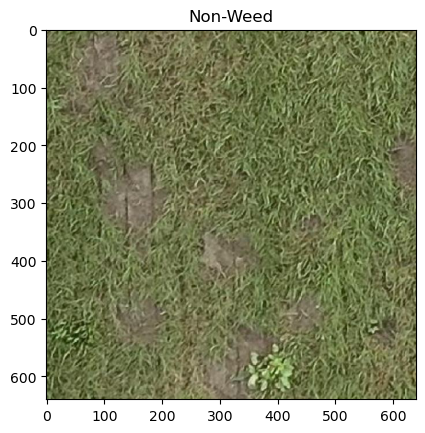

In [19]:
import os
import numpy as np
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator, load_img, img_to_array
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
import matplotlib.pyplot as plt

train_dir = r"C:\Users\subhash\Downloads\dataset\train"
test_dir = r"C:\Users\subhash\Downloads\dataset\test"
img_size = (150, 150) 
batch_size = 32

train_datagen = ImageDataGenerator(
    rescale=1.0 / 255,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode="nearest",
    validation_split=0.2, 
)

test_datagen = ImageDataGenerator(rescale=1.0 / 255)

train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=img_size,
    batch_size=batch_size,
    class_mode="binary",
    subset="training",
)

validation_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=img_size,
    batch_size=batch_size,
    class_mode="binary",
    subset="validation",
)

test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=img_size,
    batch_size=batch_size,
    class_mode="binary",
)

# 3. Build CNN Model
model = Sequential([
    Conv2D(32, (3, 3), activation="relu", input_shape=(150, 150, 3)),
    MaxPooling2D(pool_size=(2, 2)),
    Conv2D(64, (3, 3), activation="relu"),
    MaxPooling2D(pool_size=(2, 2)),
    Conv2D(128, (3, 3), activation="relu"),
    MaxPooling2D(pool_size=(2, 2)),
    Flatten(),
    Dense(128, activation="relu"),
    Dropout(0.5),
    Dense(1, activation="sigmoid"), 
])

model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"],
)
early_stopping = EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True)
model_checkpoint = ModelCheckpoint(
    "best_model.keras", 
    monitor="val_loss",
    save_best_only=True
)

history = model.fit(
    train_generator,
    steps_per_epoch=train_generator.samples // batch_size,
    validation_data=validation_generator,
    validation_steps=validation_generator.samples // batch_size,
    epochs=20,
    callbacks=[early_stopping, model_checkpoint],
)
test_loss, test_accuracy = model.evaluate(test_generator)
print(f"Test Accuracy: {test_accuracy * 100:.2f}%")
model.save("weed_detection_model.keras")
def preprocess_image(img_path, img_size=(150, 150)):
    img = load_img(img_path, target_size=img_size)
    img_array = img_to_array(img)
    img_array = img_array / 255.0
    img_array = np.expand_dims(img_array, axis=0)
    return img_array

def predict_weed(img_path):
 
    img_array = preprocess_image(img_path)
   
    prediction = model.predict(img_array)
  
    if prediction > 0.5:
        print(f"The image is a weed with {prediction[0][0] * 100:.2f}% confidence.")
    else:
        print(f"The image is not a weed with {(1 - prediction[0][0]) * 100:.2f}% confidence.")
        
    
    img = load_img(img_path)
    plt.imshow(img)
    plt.title("Weed" if prediction > 0.5 else "Non-Weed")
    plt.show()


img_path = r"C:\Users\subhash\Downloads\dataset\test\non-weeds\ridderzuring_4583_jpg.rf.2ad484b71eeddb3ac67e2a2ec73a5bd6.jpg" 
predict_weed(img_path)
